In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from model import *
from utilities import *
from loss_ftn import *


In [2]:
PATH = "D:\\01_Datasets\\Curriculum Learning\\"

data_dims = np.shape(np.load(PATH + "true_results_multiwl\\result_Hy_"+f'{0:08d}'+'k'+str(0.01).zfill(4)+".npy")[0])

In [3]:
P = 1000
t = 500
N_L = 15
N_C = 64

dx = P/N_C
dz = t/N_L

wl_list = list(range(650, 751, 10))

n_test = 1000
batch_size = 250
k = 0

In [4]:
layer_finetune = 10
model_baseline = FNOModel2d(modes=16, width=32, blocks=layer_finetune).cuda()
model_f_dirtl = FNOModel2d(modes=16, width=32, blocks=layer_finetune).cuda()
model_l_dirtl = FNOModel2d(modes=16, width=32, blocks=layer_finetune).cuda()

In [5]:
SAVE_f_dirtl = f"DIRTL_{9.0 :.2f}k_freeze_{layer_finetune}FL.pth"
SAVE_l_dirtl = f"DIRTL_{9.0 :.2f}k_loose_{layer_finetune}FL.pth"
SAVE_baseline = f"DIRTL_{9.0:.2f}k_baseline_{layer_finetune}FL.pth"

In [6]:
model_baseline.load_state_dict(torch.load(SAVE_baseline))
model_l_dirtl.load_state_dict(torch.load(SAVE_l_dirtl))
model_f_dirtl.load_state_dict(torch.load(SAVE_f_dirtl))

<All keys matched successfully>

In [7]:
data_loader = data_loader_test(n_test, batch_size, wl_list, data_dims, k, dz)

Loading Test Data: 100%|██████████| 1000/1000 [01:00<00:00, 16.63it/s]


In [8]:
L1_f_dirtl, L2_f_dirtl, rel_L1_f_dirtl, rel_L2_f_dirtl, max_amplitudes_f_dirtl = rel_err(model_f_dirtl, data_loader )
print("1 done")
L1_baseline, L2_baseline, rel_L1_baseline, rel_L2_baseline, max_amplitudes_baseline = rel_err(model_baseline, data_loader)
print("2 done")
L1_l_dirtl, L2_l_dirtl, rel_L1_l_dirtl, rel_L2_l_dirtl, max_amplitudes_l_dirtl = rel_err(model_l_dirtl, data_loader )
print("3 done")

1 done
2 done
3 done


In [9]:
del model_baseline, model_f_dirtl, model_l_dirtl

In [10]:
avg_L1_f_dirtl       = np.mean(L1_f_dirtl)
avg_L2_f_dirtl       = np.mean(L2_f_dirtl)
avg_rel_L1_f_dirtl   = np.mean(rel_L1_f_dirtl)
avg_rel_L2_f_dirtl   = np.mean(rel_L2_f_dirtl)

avg_L1_l_dirtl       = np.mean(L1_l_dirtl)
avg_L2_l_dirtl       = np.mean(L2_l_dirtl)
avg_rel_L1_l_dirtl   = np.mean(rel_L1_l_dirtl)
avg_rel_L2_l_dirtl   = np.mean(rel_L2_l_dirtl)

# Compute averages for baseline
avg_L1_baseline         = np.mean(L1_baseline)
avg_L2_baseline         = np.mean(L2_baseline)
avg_rel_L1_baseline     = np.mean(rel_L1_baseline)
avg_rel_L2_baseline     = np.mean(rel_L2_baseline)

print("F-DIRTL averages:")
print(f"L1: {avg_L1_f_dirtl}, L2: {avg_L2_f_dirtl}, rel_L1: {avg_rel_L1_f_dirtl}, rel_L2: {avg_rel_L2_f_dirtl}")

print("L-DIRTL averages:")
print(f"L1: {avg_L1_l_dirtl}, L2: {avg_L2_l_dirtl}, rel_L1: {avg_rel_L1_l_dirtl}, rel_L2: {avg_rel_L2_l_dirtl}")

print("baseline averages:")
print(f"L1: {avg_L1_baseline}, L2: {avg_L2_baseline}, rel_L1: {avg_rel_L1_baseline}, rel_L2: {avg_rel_L2_baseline}")


F-DIRTL averages:
L1: 164.72642517089844, L2: 3.265389919281006, rel_L1: 0.02078106626868248, rel_L2: 0.02806706354022026
L-DIRTL averages:
L1: 370.33624267578125, L2: 6.4741010665893555, rel_L1: 0.04796023666858673, rel_L2: 0.05779825150966644
baseline averages:
L1: 367.841064453125, L2: 6.35178279876709, rel_L1: 0.04795721918344498, rel_L2: 0.05723966658115387


In [11]:
# Example bin edges for max amplitudes (log-spaced is often better for wide ranges)
bins = np.logspace(np.log10(min(max_amplitudes_baseline + max_amplitudes_f_dirtl)),
                   np.log10(max(max_amplitudes_baseline + max_amplitudes_f_dirtl)), 
                   15)  # 15 bins

# Histogram for Baseline
hist_v, edges = np.histogram(max_amplitudes_baseline, bins=bins, weights=rel_L2_baseline)
count_v, _ = np.histogram(max_amplitudes_baseline, bins=bins)
avg_error_v = hist_v / count_v  # average error per bin

# Histogram for Transfer
hist_tl, _ = np.histogram(max_amplitudes_f_dirtl, bins=bins, weights=rel_L2_f_dirtl)
count_tl, _ = np.histogram(max_amplitudes_f_dirtl, bins=bins)
avg_error_tl = hist_tl / count_tl

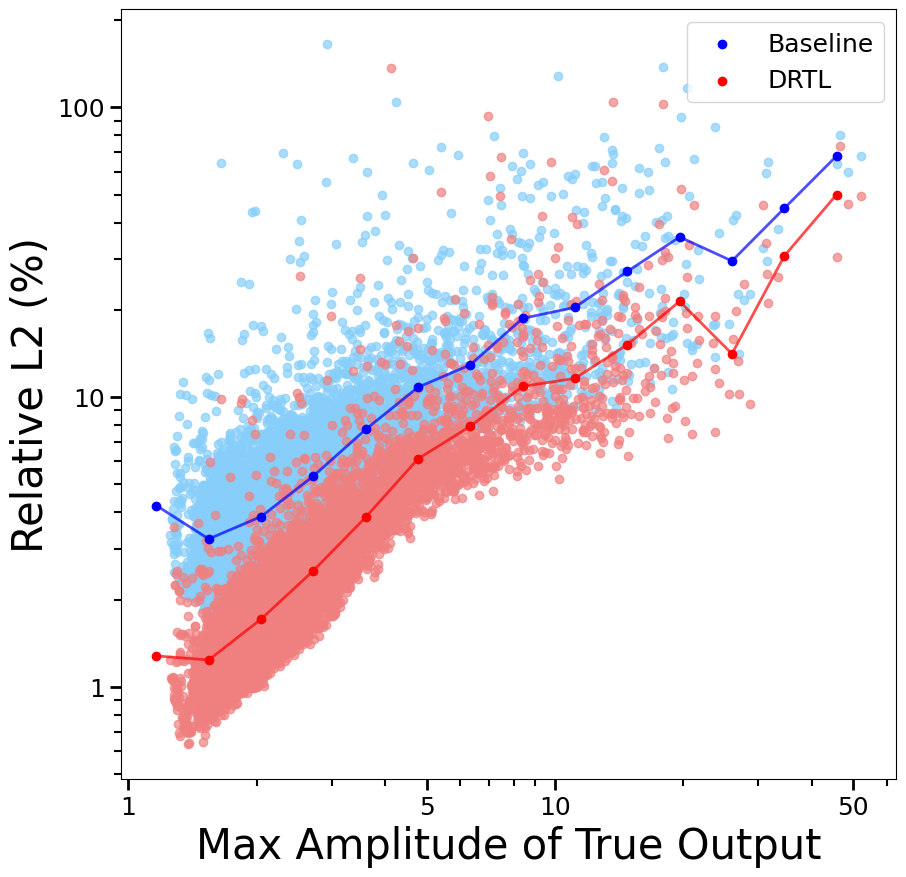

In [ ]:
import matplotlib.ticker as ticker

figure_size = (10, 10)
plt.figure(figsize=figure_size)

# Scatter plot (error distribution)
plt.scatter(max_amplitudes_baseline, np.array(rel_L2_baseline) * 100, alpha=0.7, color='lightskyblue', marker="o")
plt.scatter(max_amplitudes_f_dirtl, np.array(rel_L2_f_dirtl) * 100, alpha=0.7, color='lightcoral', marker="o")

# Histogram binning for average error
bins = np.logspace(np.log10(1),  # extend bins down to 1
                   np.log10(max(max_amplitudes_baseline + max_amplitudes_f_dirtl)), 
                   15)  # 15 bins

# Baseline
hist_v, edges = np.histogram(max_amplitudes_baseline, bins=bins, weights=rel_L2_baseline)
count_v, _ = np.histogram(max_amplitudes_baseline, bins=bins)
avg_error_v = hist_v / count_v

# Transfer
hist_tl, _ = np.histogram(max_amplitudes_f_dirtl, bins=bins, weights=rel_L2_f_dirtl)
count_tl, _ = np.histogram(max_amplitudes_f_dirtl, bins=bins)
avg_error_tl = hist_tl / count_tl

bin_centers = (edges[:-1] + edges[1:]) / 2

# Plot average errors on top of scatter with white outline
plt.scatter(bin_centers, avg_error_v * 100, color='b', edgecolor='b', s=100, linewidth=2, label='Baseline', zorder=5, marker=".")
plt.scatter(bin_centers, avg_error_tl * 100, color='r', edgecolor='r', s=100, linewidth=2, label='f-DIRTL', zorder=5, marker=".")

# Connect markers with lines for clarity
plt.plot(bin_centers, avg_error_v * 100, color='b', linestyle='-', linewidth=2, alpha=0.7, zorder=4)
plt.plot(bin_centers, avg_error_tl * 100, color='r', linestyle='-', linewidth=2, alpha=0.7, zorder=4)

# Log scales
plt.xscale('log')
plt.yscale('log')

# Axis labels
plt.xlabel('Max Amplitude of True Output', fontsize=30)
plt.ylabel('Relative L2 (%)', fontsize=30)

# Y axis formatting
plt.gca().yaxis.set_major_formatter(ticker.ScalarFormatter())
plt.gca().ticklabel_format(style='plain', axis='y')
plt.yticks([1, 10, 100], labels=["1", "10", "100"], fontsize=18)

# X axis formatting
plt.xticks([1, 5, 10, 50], labels=["1", "5", "10", "50"], fontsize=18)

# Tick size
plt.tick_params(axis='both', which='major', length=8, width=2)
plt.tick_params(axis='both', which='minor', length=5, width=1.5)

# plt.grid(True, which='both', ls='--', alpha=0.5)
plt.legend(fontsize=18)
plt.show()
